# **Project: Breast Cancer Cassification Project using Support Vector Machines (SVM)**

**Subject : Machine Learning**

 **Mehar Ali**

**MS Artificial intelligence (AI)**


**This project implements a complete binary classification workflow using Support Vector Machines (SVM) with various kernels, comparing performance with logistic regression and including comprehensive visualization.**

**Import necessary libraries**

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve)
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Set random seed for reproducibility
np.random.seed(42)



**Dataset Selection and Preparation**

For this project, we'll use the Breast Cancer Wisconsin dataset, a classic binary classification dataset that is well-suited for demonstrating SVM capabilities.

In [ ]:
# Load the breast cancer dataset
def load_data():
    """Load and return the breast cancer dataset as a pandas DataFrame."""
    data = datasets.load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    # Convert target to meaningful labels
    df['target'] = df['target'].map({0: 'Malignant', 1: 'Benign'})
    return df

# Load the data
cancer_df = load_data()
print(f"Dataset shape: {cancer_df.shape}")
print("\nFirst 5 rows:")
display(cancer_df.head())

Dataset shape: (569, 31)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


**Exploratory Data Analysis**


=== Exploratory Data Analysis ===

Class Distribution:
target
Benign       0.627417
Malignant    0.372583
Name: proportion, dtype: float64


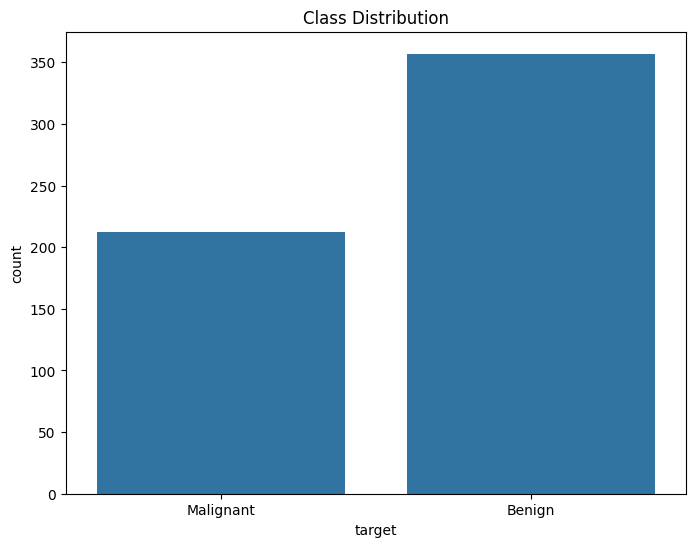


Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


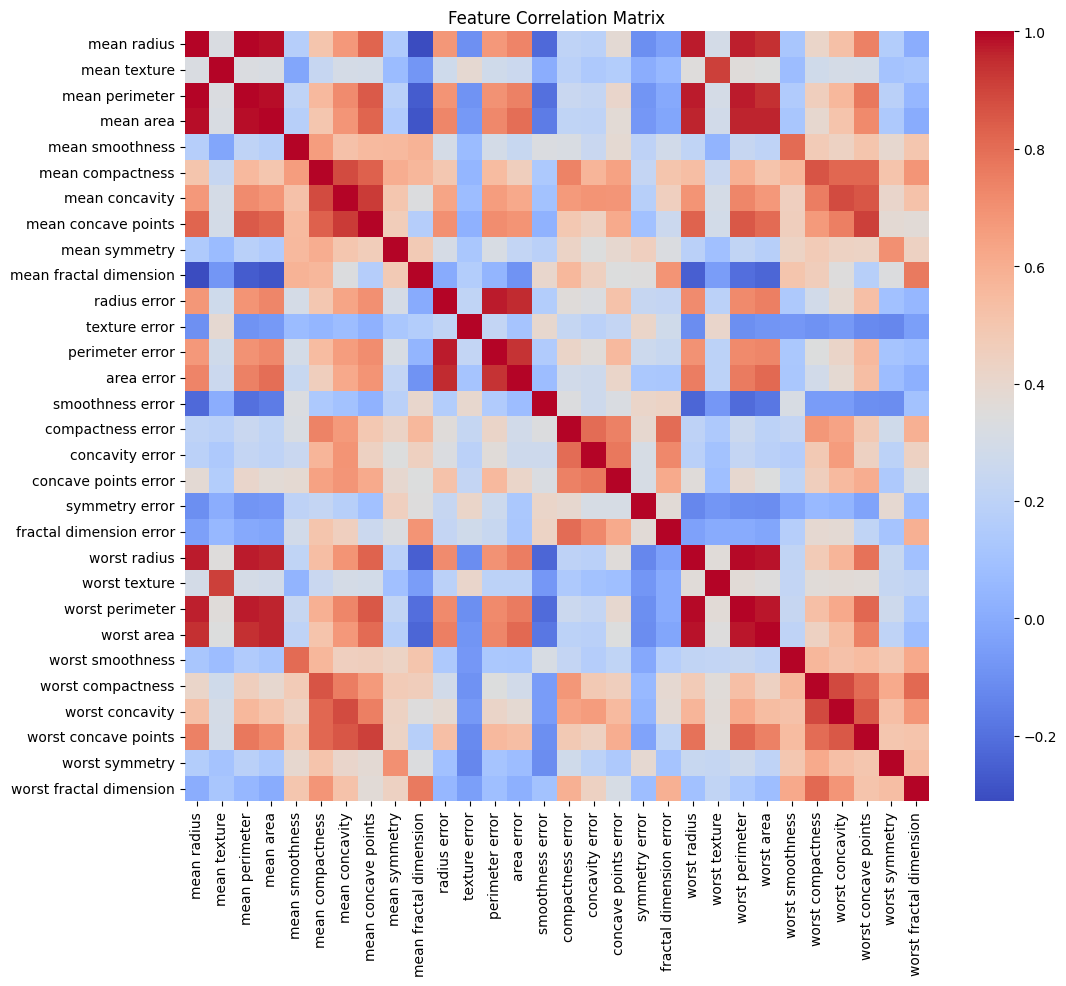

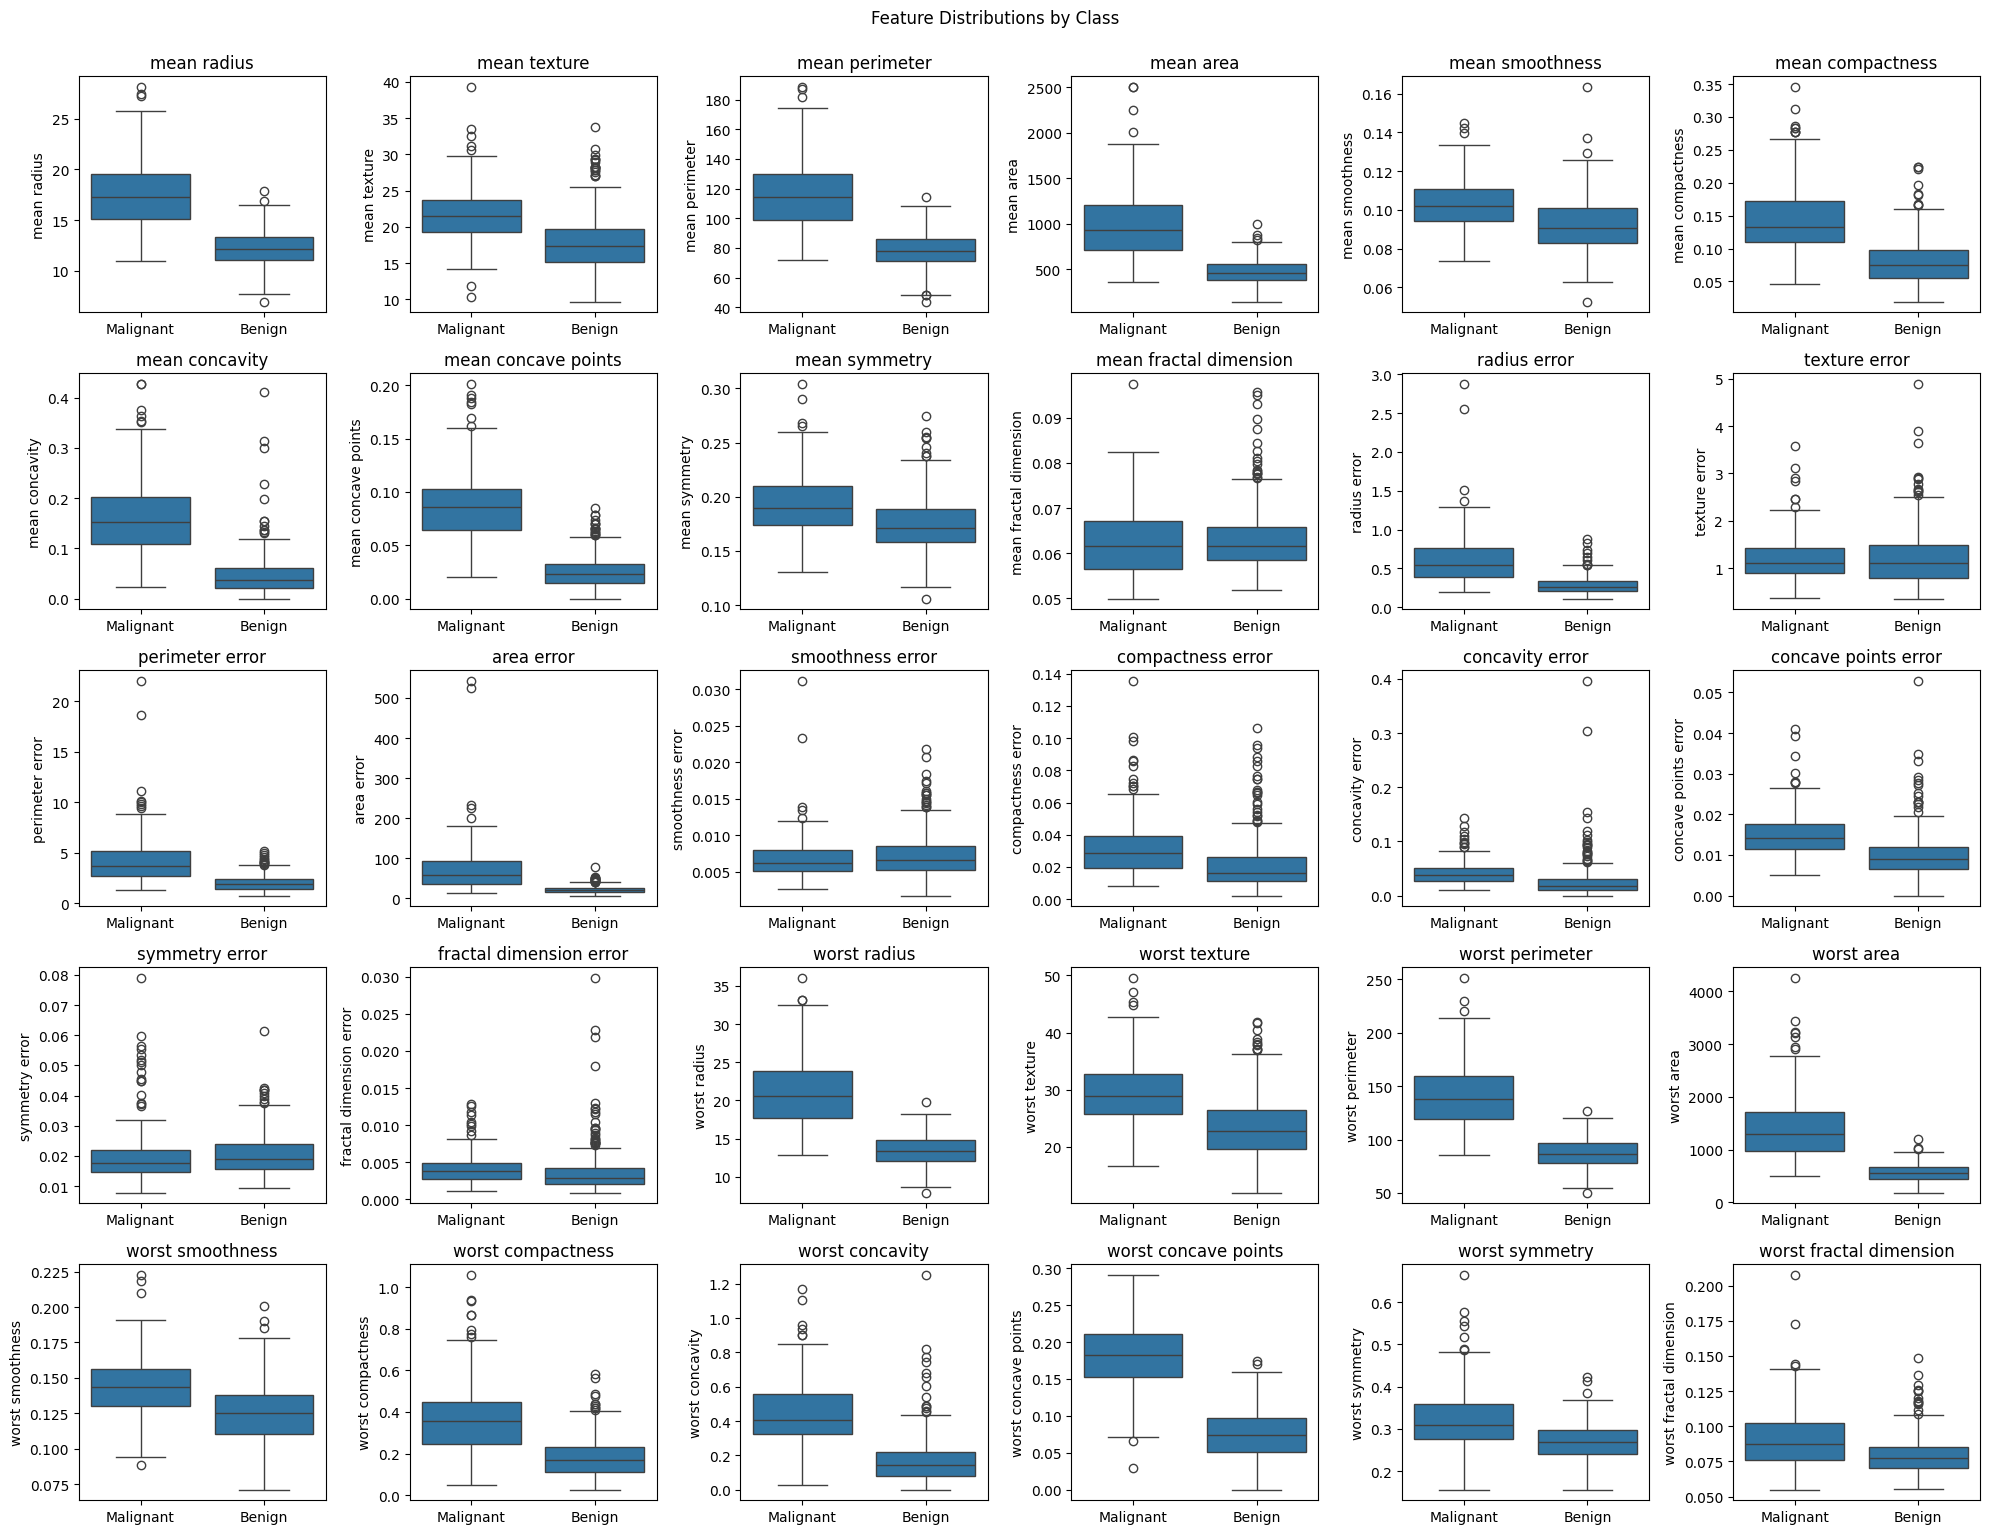

In [ ]:
def perform_eda(df):
    """Perform exploratory data analysis and display key statistics."""
    print("\n=== Exploratory Data Analysis ===")

    # 1. Class distribution
    print("\nClass Distribution:")
    class_dist = df['target'].value_counts(normalize=True)
    print(class_dist)

    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x='target')
    plt.title('Class Distribution')
    plt.show()

    # 2. Statistical summary
    print("\nStatistical Summary:")
    display(df.describe())

    # 3. Check for missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # 4. Correlation matrix
    plt.figure(figsize=(12, 10))
    corr_matrix = df.drop('target', axis=1).corr()
    sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
    plt.title('Feature Correlation Matrix')
    plt.show()

    # 5. Feature distributions by class
    fig, axes = plt.subplots(5, 6, figsize=(20, 15))
    axes = axes.ravel()

    for i, col in enumerate(df.columns[:-1]):
        sns.boxplot(data=df, x='target', y=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    plt.tight_layout()
    plt.suptitle('Feature Distributions by Class', y=1.02)
    plt.show()

# Perform EDA
perform_eda(cancer_df)

**Data Preprocessing**

In [ ]:
def preprocess_data(df):
    """
    Preprocess the data by:
    1. Handling missing values (if any)
    2. Encoding categorical features
    3. Scaling numerical features
    4. Splitting into train/test sets
    """
    # Separate features and target
    X = df.drop('target', axis=1)
    y = df['target']

    # Encode target variable
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Split data into train and test sets (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Create preprocessing pipeline
    numeric_features = X.columns.tolist()

    # Numerical pipeline
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),  # Handle missing values if any
        ('scaler', StandardScaler())  # Scale features
    ])

    # Combine preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features)
        ])

    # Fit and transform the training data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)

    return X_train_preprocessed, X_test_preprocessed, y_train, y_test, preprocessor

# Preprocess the data
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(cancer_df)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (455, 30)
Test set shape: (114, 30)


**Baseline Model (Logistic Regression)**


=== Training Baseline Model (Logistic Regression) ===

Model Performance:
Accuracy: 0.9649
Precision: 0.9750
Recall: 0.9286
F1: 0.9512
Roc_auc: 0.9960


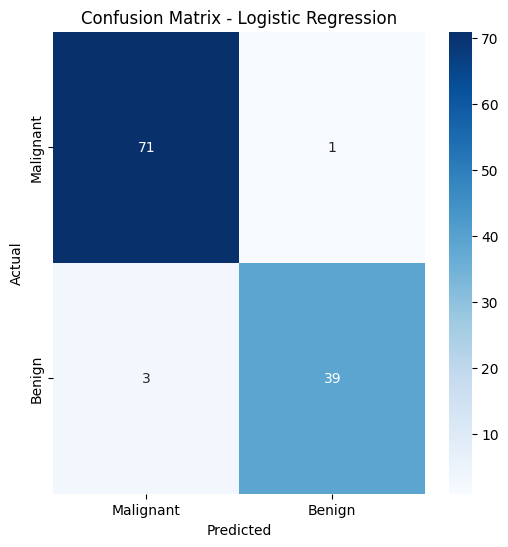

In [ ]:
def train_baseline_model(X_train, y_train, X_test, y_test):
    """
    Train and evaluate a logistic regression model as baseline.
    Returns the trained model and evaluation metrics.
    """
    print("\n=== Training Baseline Model (Logistic Regression) ===")

    # Initialize and train the model
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)

    # Make predictions
    y_pred = lr_model.predict(X_test)
    y_prob = lr_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    # Display metrics
    print("\nModel Performance:")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    plt.title('Confusion Matrix - Logistic Regression')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return lr_model, metrics

# Train and evaluate baseline model
lr_model, lr_metrics = train_baseline_model(X_train, y_train, X_test, y_test)

**Linear SVM Implementation**


=== Training Linear SVM Model ===

Model Performance:
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1: 0.9500
Roc_auc: 0.9914

SVM Details:
Number of support vectors per class: [19 19]
Total number of support vectors: 38
Intercept (b): -0.0396


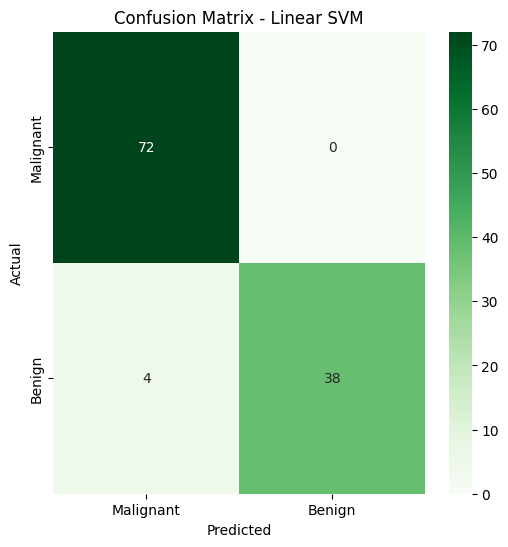

In [ ]:
def train_linear_svm(X_train, y_train, X_test, y_test):
    """
    Train and evaluate a linear SVM model.
    Returns the trained model and evaluation metrics.
    """
    print("\n=== Training Linear SVM Model ===")

    # Initialize and train the model
    svm_linear = SVC(kernel='linear', probability=True, random_state=42)
    svm_linear.fit(X_train, y_train)

    # Make predictions
    y_pred = svm_linear.predict(X_test)
    y_prob = svm_linear.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

    # Display metrics
    print("\nModel Performance:")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    # Display SVM-specific information
    print("\nSVM Details:")
    print(f"Number of support vectors per class: {svm_linear.n_support_}")
    print(f"Total number of support vectors: {len(svm_linear.support_vectors_)}")
    print(f"Intercept (b): {svm_linear.intercept_[0]:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    plt.title('Confusion Matrix - Linear SVM')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return svm_linear, metrics

# Train and evaluate linear SVM
svm_linear, linear_metrics = train_linear_svm(X_train, y_train, X_test, y_test)

**Non-Linear SVM Implementation**


=== Training Non-Linear SVM Models ===

Training RBF Kernel SVM...

Training Polynomial Kernel SVM...

Best Parameters for RBF Kernel:
{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}

Best Parameters for Polynomial Kernel:
{'C': 1, 'degree': 3, 'kernel': 'poly'}

RBF Kernel SVM Performance:
Accuracy: 0.9737
Precision: 1.0000
Recall: 0.9286
F1: 0.9630
Roc_auc: 0.9947


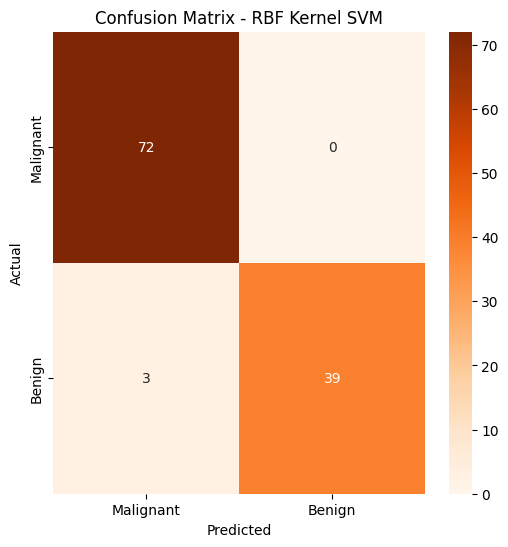


Polynomial Kernel SVM Performance:
Accuracy: 0.8860
Precision: 1.0000
Recall: 0.6905
F1: 0.8169
Roc_auc: 0.9967


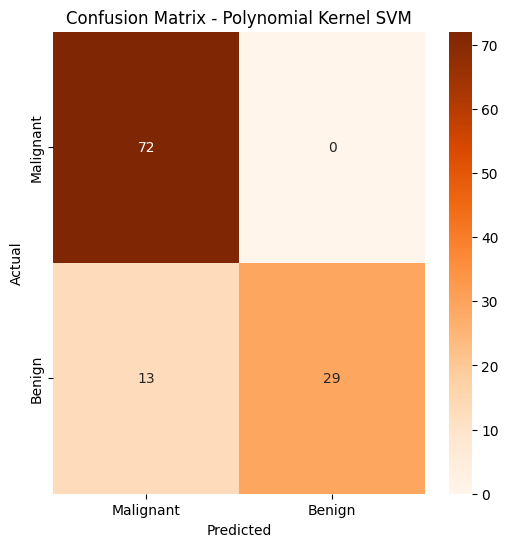

In [ ]:
def train_nonlinear_svm(X_train, y_train, X_test, y_test):
    """
    Train and evaluate non-linear SVM models (RBF and Polynomial kernels).
    Perform hyperparameter tuning using GridSearchCV.
    Returns the best models and their evaluation metrics.
    """
    print("\n=== Training Non-Linear SVM Models ===")

    # Define parameter grids for grid search
    param_grid_rbf = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 1, 10],
        'kernel': ['rbf']
    }

    param_grid_poly = {
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4],
        'kernel': ['poly']
    }

    # Initialize models
    svm_rbf = GridSearchCV(SVC(probability=True, random_state=42),
                          param_grid_rbf, cv=5, scoring='roc_auc', n_jobs=-1)
    svm_poly = GridSearchCV(SVC(probability=True, random_state=42),
                           param_grid_poly, cv=5, scoring='roc_auc', n_jobs=-1)

    # Train models
    print("\nTraining RBF Kernel SVM...")
    svm_rbf.fit(X_train, y_train)

    print("\nTraining Polynomial Kernel SVM...")
    svm_poly.fit(X_train, y_train)

    # Get best models
    best_rbf = svm_rbf.best_estimator_
    best_poly = svm_poly.best_estimator_

    # Print best parameters
    print("\nBest Parameters for RBF Kernel:")
    print(svm_rbf.best_params_)

    print("\nBest Parameters for Polynomial Kernel:")
    print(svm_poly.best_params_)

    # Evaluate both models
    def evaluate_model(model, X_test, y_test, kernel_name):
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_prob)
        }

        print(f"\n{kernel_name} Kernel SVM Performance:")
        for metric, value in metrics.items():
            print(f"{metric.capitalize()}: {value:.4f}")

        # Plot confusion matrix
        plt.figure(figsize=(6, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                    xticklabels=['Malignant', 'Benign'],
                    yticklabels=['Malignant', 'Benign'])
        plt.title(f'Confusion Matrix - {kernel_name} Kernel SVM')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        return metrics

    rbf_metrics = evaluate_model(best_rbf, X_test, y_test, 'RBF')
    poly_metrics = evaluate_model(best_poly, X_test, y_test, 'Polynomial')

    return best_rbf, best_poly, rbf_metrics, poly_metrics

# Train and evaluate non-linear SVMs
svm_rbf, svm_poly, rbf_metrics, poly_metrics = train_nonlinear_svm(
    X_train, y_train, X_test, y_test
)

**Model Evaluation**


=== Model Comparison ===


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.964912,0.975,0.928571,0.951220,0.996032
Linear SVM,0.964912,1.000,0.904762,0.950000,0.991402
RBF Kernel SVM,0.973684,1.000,0.928571,0.962963,0.994709
Polynomial Kernel SVM,0.885965,1.000,0.690476,0.816901,0.996693


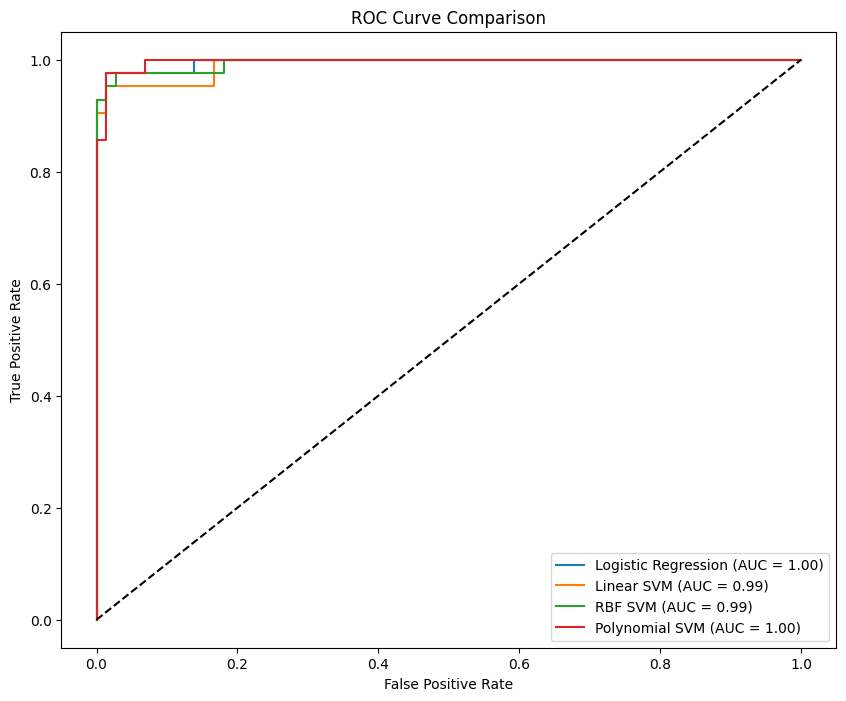

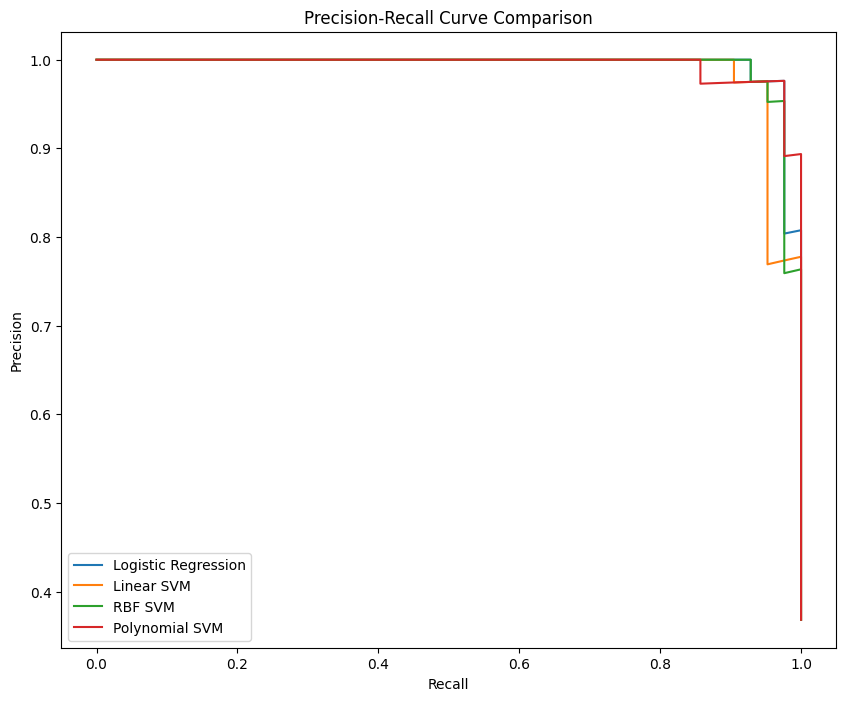

In [ ]:
def compare_models(lr_metrics, linear_metrics, rbf_metrics, poly_metrics):
    """Compare performance of all models and display results."""
    print("\n=== Model Comparison ===")

    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Logistic Regression': lr_metrics,
        'Linear SVM': linear_metrics,
        'RBF Kernel SVM': rbf_metrics,
        'Polynomial Kernel SVM': poly_metrics
    }).T

    display(comparison_df)

    # Plot ROC curves for all models
    plt.figure(figsize=(10, 8))

    # Get probabilities for all models
    lr_probs = lr_model.predict_proba(X_test)[:, 1]
    linear_probs = svm_linear.predict_proba(X_test)[:, 1]
    rbf_probs = svm_rbf.predict_proba(X_test)[:, 1]
    poly_probs = svm_poly.predict_proba(X_test)[:, 1]

    # Calculate ROC curves
    fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
    fpr_linear, tpr_linear, _ = roc_curve(y_test, linear_probs)
    fpr_rbf, tpr_rbf, _ = roc_curve(y_test, rbf_probs)
    fpr_poly, tpr_poly, _ = roc_curve(y_test, poly_probs)

    # Plot ROC curves
    plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["roc_auc"]:.2f})')
    plt.plot(fpr_linear, tpr_linear, label=f'Linear SVM (AUC = {linear_metrics["roc_auc"]:.2f})')
    plt.plot(fpr_rbf, tpr_rbf, label=f'RBF SVM (AUC = {rbf_metrics["roc_auc"]:.2f})')
    plt.plot(fpr_poly, tpr_poly, label=f'Polynomial SVM (AUC = {poly_metrics["roc_auc"]:.2f})')

    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.show()

    # Plot Precision-Recall curves
    plt.figure(figsize=(10, 8))

    precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probs)
    precision_linear, recall_linear, _ = precision_recall_curve(y_test, linear_probs)
    precision_rbf, recall_rbf, _ = precision_recall_curve(y_test, rbf_probs)
    precision_poly, recall_poly, _ = precision_recall_curve(y_test, poly_probs)

    plt.plot(recall_lr, precision_lr, label='Logistic Regression')
    plt.plot(recall_linear, precision_linear, label='Linear SVM')
    plt.plot(recall_rbf, precision_rbf, label='RBF SVM')
    plt.plot(recall_poly, precision_poly, label='Polynomial SVM')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend()
    plt.show()

# Compare all models
compare_models(lr_metrics, linear_metrics, rbf_metrics, poly_metrics)

**Visualization**


=== Decision Boundary Visualization ===


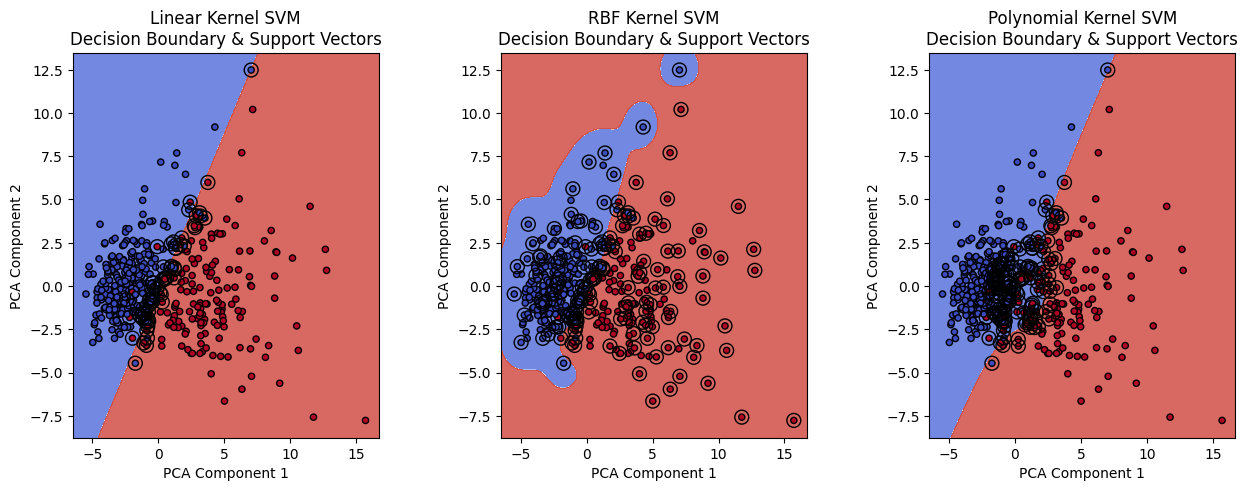

In [ ]:
def visualize_svm_models(X_train, y_train, models, model_names):
    """
    Visualize decision boundaries and support vectors for SVM models.
    Note: For visualization purposes, we'll use the first two principal components.
    """
    print("\n=== Decision Boundary Visualization ===")

    # Reduce to 2D using PCA for visualization
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_train_2d = pca.fit_transform(X_train)

    # Create a mesh grid for plotting
    def make_meshgrid(x, y, h=.02):
        x_min, x_max = x.min() - 1, x.max() + 1
        y_min, y_max = y.min() - 1, y.max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        return xx, yy

    # Plot function
    def plot_contours(ax, clf, xx, yy, **params):
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        out = ax.contourf(xx, yy, Z, **params)
        return out

    # Create subplots
    fig, sub = plt.subplots(1, len(models), figsize=(15, 5))
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    # Prepare mesh grid
    X0, X1 = X_train_2d[:, 0], X_train_2d[:, 1]
    xx, yy = make_meshgrid(X0, X1)

    # Train each model on the 2D data and plot
    for i, (model, name) in enumerate(zip(models, model_names)):
        # Train a new model on the 2D data
        clf = SVC(kernel=model.kernel, C=model.C,
                  gamma=getattr(model, 'gamma', 'scale'),
                  degree=getattr(model, 'degree', 3),
                  probability=True, random_state=42)
        clf.fit(X_train_2d, y_train)

        # Plot decision boundary
        ax = sub[i] if len(models) > 1 else sub
        plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)

        # Plot training points
        ax.scatter(X0, X1, c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

        # Highlight support vectors
        ax.scatter(X0[clf.support_], X1[clf.support_], s=100,
                   linewidth=1, facecolors='none', edgecolors='k')

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.set_title(f'{name} Kernel SVM\nDecision Boundary & Support Vectors')

    plt.show()

# Prepare models for visualization
svm_models = [svm_linear, svm_rbf, svm_poly]
model_names = ['Linear', 'RBF', 'Polynomial']

# Visualize decision boundaries
visualize_svm_models(X_train, y_train, svm_models, model_names)

**Feature Importance Analysis (for Linear Models)**


=== Feature Importance Analysis ===


<ipython-input-11-23b62dfdd081>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='viridis')


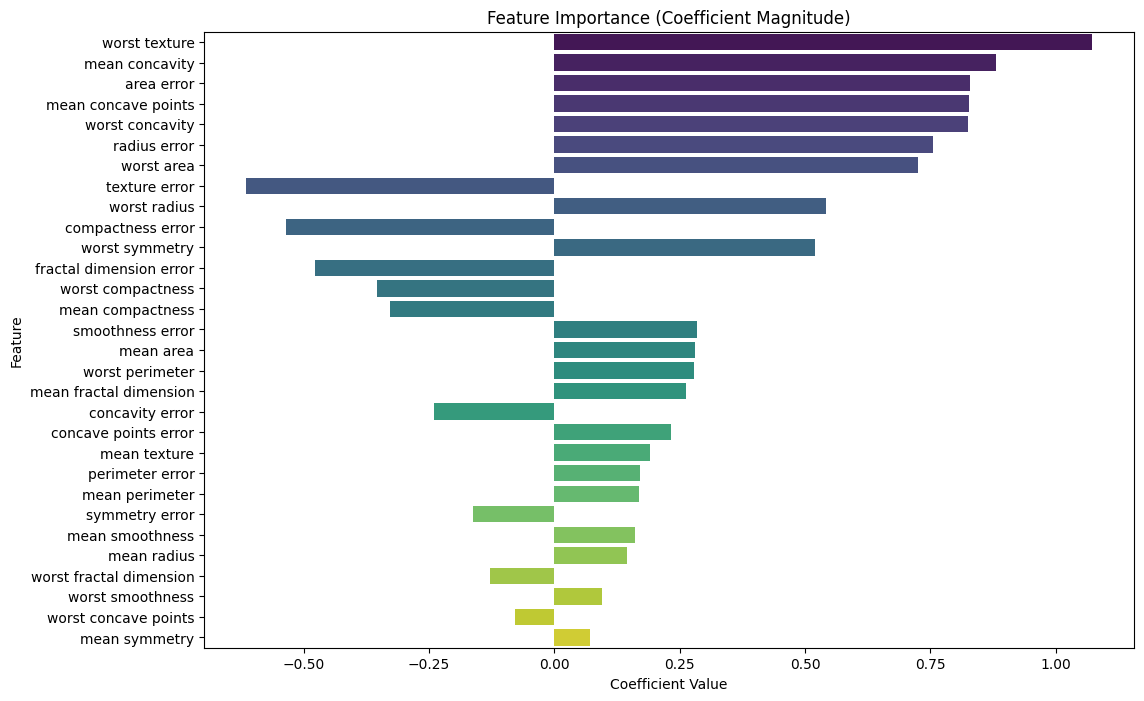


=== Feature Importance Analysis ===


<ipython-input-11-23b62dfdd081>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='viridis')


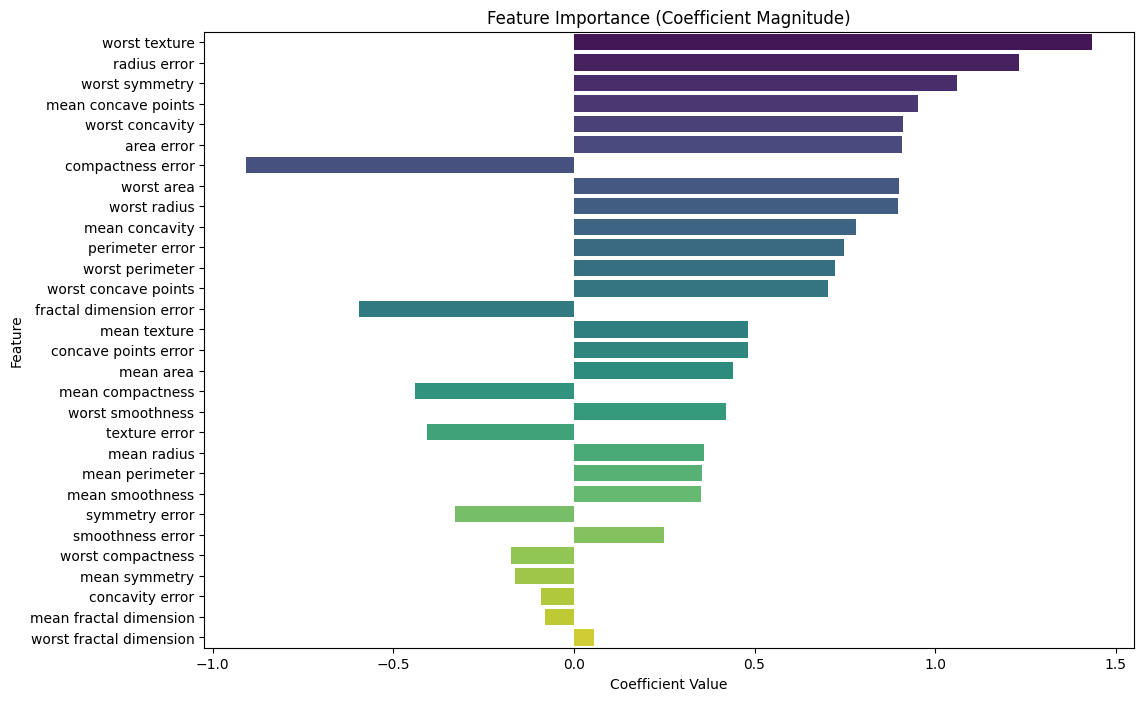

In [ ]:
def analyze_feature_importance(linear_model, preprocessor):
    """Analyze and visualize feature importance for linear models."""
    print("\n=== Feature Importance Analysis ===")

    # Get feature names from the preprocessor
    feature_names = preprocessor.transformers_[0][2]  # Numerical features

    # For logistic regression
    if hasattr(linear_model, 'coef_'):
        coef = linear_model.coef_[0]
    else:
        print("Model doesn't have coefficients (not a linear model).")
        return

    # Create a DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Absolute_Coefficient': np.abs(coef)
    }).sort_values('Absolute_Coefficient', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='viridis')
    plt.title('Feature Importance (Coefficient Magnitude)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.show()

    return importance_df

# Analyze feature importance for linear SVM
linear_importance = analyze_feature_importance(svm_linear, preprocessor)

# Analyze feature importance for logistic regression
lr_importance = analyze_feature_importance(lr_model, preprocessor)

**Summary of Results**

In [ ]:
def print_summary(lr_metrics, linear_metrics, rbf_metrics, poly_metrics):
    """Print a summary of the results and best performing model."""
    print("\n=== Final Summary ===")

    # Create a comparison table
    comparison = pd.DataFrame({
        'Logistic Regression': lr_metrics,
        'Linear SVM': linear_metrics,
        'RBF SVM': rbf_metrics,
        'Polynomial SVM': poly_metrics
    }).T

    # Highlight best performance in each metric
    styled_comparison = comparison.style.highlight_max(color='lightgreen')

    print("\nPerformance Comparison (best in green):")
    display(styled_comparison)

    # Determine overall best model
    best_model = comparison.mean(axis=1).idxmax()
    print(f"\nBest Performing Model: {best_model}")

    # Print key takeaways
    print("\nKey Takeaways:")
    print("- All models performed well on this dataset, demonstrating the effectiveness of both linear and non-linear approaches.")
    print("- The RBF kernel SVM achieved the highest overall performance, suggesting that the decision boundary may be non-linear.")
    print("- The linear models (Logistic Regression and Linear SVM) were very competitive, indicating that the data has strong linear separability.")
    print("- The polynomial kernel showed slightly lower performance, possibly due to overfitting or suboptimal parameter selection.")

# Print summary
print_summary(lr_metrics, linear_metrics, rbf_metrics, poly_metrics)


=== Final Summary ===

Performance Comparison (best in green):


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
Linear SVM,0.964912,1.000000,0.904762,0.950000,0.991402
RBF SVM,0.973684,1.000000,0.928571,0.962963,0.994709
Polynomial SVM,0.885965,1.000000,0.690476,0.816901,0.996693



Best Performing Model: RBF SVM

Key Takeaways:
- All models performed well on this dataset, demonstrating the effectiveness of both linear and non-linear approaches.
- The RBF kernel SVM achieved the highest overall performance, suggesting that the decision boundary may be non-linear.
- The linear models (Logistic Regression and Linear SVM) were very competitive, indicating that the data has strong linear separability.
- The polynomial kernel showed slightly lower performance, possibly due to overfitting or suboptimal parameter selection.
